In [35]:
import numpy as np
from scipy.optimize import fsolve
import pandas as pd
import matplotlib.pyplot as plt

### Notes
This is the v0.2 version of the MTOW Estimation code. It is identical to the v0 version, but just has been packaged all in one function to allow easier handling. Trade studies on various design parameters have also been performed.

In [36]:
crew_and_payload = {
    "W_crew"    : 200,  # Crew weight, LBS
    "n_aim9x"   : 2,    # Number of AIM-9xs carried
    "n_mk83"    : 4,    # Number of MK-83s carried
    "n_aim120"  : 0,    # Number of AIM-120Cs carried
    "m_aim9x"   : 190,  # Weight AIM-9X, LBS
    "m_aim120"  : 360,  # Weight AIM-190C, LBS
    "m_mk83"    : 1000, # Weight MK-83 JDAM, LBS
    "avionics"  : 2500,    # Avionics weight, LBS
}

performance = {
    "M_cruise"  : 0.85,     # Cruise mach speed
    "h_cruise"  : 40000,    # Cruise altitude, FT
    "a_cruise"  : 967.6,    # Speed of sound at cruise, FT/s
    "R_cruise"  : 700,      # Cruise distance (Combat Radius), Nautical Miles
    "E_loiter"  : 20,       # Loiter time, min
    "M_dash"    : 0.85,     # Dash mach speed
    "a_dash"    : 1116,     # Speed of sound at SL, FT/s
    "R_dash"    : 100,      # Dash distnace, Nautical Miles
    "C_cruise"  : 0.8,      # Engine SFC in Cruise, 1/hr
    "C_dash"    : 1.0,      # Engine SFC in Dash (Max-non-afterburning), 1/hr
    "C_loiter"  : 0.7,      # Engine SFC in Loiter, 1/hr
    "C_after"   : 1.8,      # Engine SFC with Afterburner, 1/hr
    "E_combat"  : 2,        # Combat time, min
    "AR"        : 3.24557,        # Estimated Aspect Ratio
    "Swet_Sref" : 4.17,        # Guess of Wetted Area Ratio
    "K_LD"      : 14,       # Factor in calculating L/D_max
}

mission_sequence = [1, 2, 3, 4, 5, 2, 3, 4, 7, 8]
# The above is the sequence of: TO, Climb, Cruise, Descent, SL Dash, Climb, Cruise, Descent, Loiter, Land. (The Strike mission)

#mission_sequence = [1, 2, 3, 6, 4, 7, 8]
# The above is the sequence of: TO, Cimb, Cruise, Combat, Descent, Loiter, Land. (Combat Mission)

empty_statistic = {
    "A": 2.34,
    "C": -0.13,
    "MTOW_guess": 40000 
}

In [37]:
def MTOW_EST(mission_sequence, A, C, MTOW_guess):
    
    # Calculation of crew and payload mass
    def crew_payload_mass(W_crew, n_aim9x, n_mk83, n_aim120, m_aim9x, m_aim120, m_mk83, avionics):
        W_payload = (n_aim9x * m_aim9x) + (n_mk83 * m_mk83) + (n_aim120 * m_aim120)
        W_crew_payload = W_crew + W_payload + avionics
        return W_crew_payload
    
    W_crew_payload = crew_payload_mass(**crew_and_payload)
    
    
    # Fixed Fuel Fractions
    ff_to = 0.970
    ff_climb = 0.985
    ff_descent = 0.99
    ff_land = 0.995


    # Cruise Fuel Fraction
    def cruise_wf(M_cruise, h_cruise, a_cruise, R_cruise, E_loiter, M_dash, a_dash, R_dash, C_cruise, C_dash, C_loiter, C_after, E_combat,
               AR, Swet_Sref, K_LD):
        R_cruise_ft = R_cruise * 6076.12
        V_cruise = M_cruise * a_cruise

        LD_max = K_LD * np.sqrt(AR / Swet_Sref)
        LD_cruise = 0.866 * LD_max

        C_cruise_s = C_cruise / 3600

        wf_cruise = np.exp((-R_cruise_ft * C_cruise_s) / (V_cruise * LD_cruise))
        
        return wf_cruise
    
    ff_cruise = cruise_wf(**performance)


    # Dash Fuel Fraction
    def dash_wf(M_cruise, h_cruise, a_cruise, R_cruise, E_loiter, M_dash, a_dash, R_dash, C_cruise, C_dash, C_loiter, C_after, E_combat,
             AR, Swet_Sref, K_LD):
        V_dash = M_dash * a_dash
        R_dash_ft = R_dash * 6076.12
        C_dash_s = C_dash / 3600
        
        LD_max = K_LD * np.sqrt(AR / Swet_Sref)
        LD_dash = 0.700 * LD_max

        wf_dash = np.exp((-R_dash_ft * C_dash_s) / (V_dash * LD_dash))    
        return wf_dash
    
    ff_dash = dash_wf(**performance)


    # Loiter Fuel Fraction
    def loiter_wf(M_cruise, h_cruise, a_cruise, R_cruise, E_loiter, M_dash, a_dash, R_dash, C_cruise, C_dash, C_loiter, C_after, E_combat,
               AR, Swet_Sref, K_LD):
        E_loiter_s = E_loiter * 60
        LD_max = K_LD * np.sqrt(AR / Swet_Sref)
        C_loiter_s = C_loiter / 3600

        wf_loiter = np.exp((-E_loiter_s * C_loiter_s) / LD_max)
        return wf_loiter
    
    ff_loiter = loiter_wf(**performance)


    # Combat Fuel Fraction
    def combat_wf(M_cruise, h_cruise, a_cruise, R_cruise, E_loiter, M_dash, a_dash, R_dash, C_cruise, C_dash, C_loiter, C_after, E_combat,
               AR, Swet_Sref, K_LD):
        E_combat_s = E_combat * 60
        C_after_s = C_after / 3600
        LD_max = K_LD * np.sqrt(AR / Swet_Sref)
        LD_combat = LD_max * 0.2

        wf_combat = np.exp((-E_combat_s * C_after_s) / LD_combat)
        return wf_combat
    
    ff_combat = combat_wf(**performance)


    ## Combined Mission Fuel Fraction
    CFF = 0
    for i, m_seq in enumerate(mission_sequence):
        if m_seq == 1:
            #print(f"Takeoff Fuel Fraction is: {ff_to}")
            CFF = ff_to
        if m_seq == 2:
            #print(f"Climb Fuel Fraction is: {ff_climb}")
            CFF = CFF * ff_climb
        if m_seq == 3:
            #print(f"Cruise Fuel Fraction is: {np.round(ff_cruise, 3)}")
            CFF = CFF * ff_cruise
        if m_seq == 4:
            #print(f"Descent Fuel Fraction is: {ff_descent}")
            CFF = CFF * ff_descent
        if m_seq == 5:
            #print(f"SL Dash Fuel Fraction is: {np.round(ff_dash, 3)}")
            CFF = CFF * ff_dash
        if m_seq == 6:
            #print(f"Combat Fuel Fraction is: {np.round(ff_combat, 3)}")
            CFF = CFF * ff_combat
        if m_seq == 7:
            #print(f"Loiter Fuel Fraction is: {np.round(ff_loiter, 3)}")
            CFF = CFF * ff_loiter
        if m_seq == 8:
            #print(f"Landing Fuel Fraction is: {ff_land}")
            CFF = CFF * ff_land

        TFF = 1.06 * (1 - CFF)
    #print(f"Fuel Fraction is: {np.round(TFF, 3)}")

    #The MTOW iterative equation
    def W0_eqn(W_0):
        return (W_crew_payload / (1 - TFF - A*W_0**C)) - W_0

    W0_est, info, status, msg = fsolve(W0_eqn, MTOW_guess, full_output=True)
    #print(f"MTOW Estimate: {np.round(W0_est)}lbs, Status: {msg}")

    W0_est = np.round(W0_est)

    #print(W0_est[0])

    # Calculation and tabulation of various weights and weight fractions
    EWF = A * W0_est**C

    EW = EWF * W0_est
    EW = np.round(EW)

    FW = TFF * W0_est
    FW = np.round(FW)
    
    AC_info = {
        'Max Takeoff Weight [lbs]': W0_est,
        'Empty Weight [lbs]': EW,
        'Fuel Weight [lbs]': FW,
        'Payload Mass [lbs]': W_crew_payload,
        'Empty Weight Fraction': np.round(EWF, 3),
        'Fuel Weight Fraction': TFF
    }

    AC_df = pd.DataFrame(AC_info)
    display(AC_df)

    return W0_est[0]
    

MTOW_EST(mission_sequence=mission_sequence, **empty_statistic)


,Max Takeoff Weight [lbs],Empty Weight [lbs],Fuel Weight [lbs],Payload Mass [lbs],Empty Weight Fraction,Fuel Weight Fraction
0,55154.0,31217.0,16857.0,7080,0.566,0.30564


np.float64(55154.0)

### Trade Study for cruise range

,Max Takeoff Weight [lbs],Empty Weight [lbs],Fuel Weight [lbs],Payload Mass [lbs],Empty Weight Fraction,Fuel Weight Fraction
0,54924.0,31103.0,16740.0,7080,0.566,0.304794


,Max Takeoff Weight [lbs],Empty Weight [lbs],Fuel Weight [lbs],Payload Mass [lbs],Empty Weight Fraction,Fuel Weight Fraction
0,57058.0,32152.0,17826.0,7080,0.564,0.312416


,Max Takeoff Weight [lbs],Empty Weight [lbs],Fuel Weight [lbs],Payload Mass [lbs],Empty Weight Fraction,Fuel Weight Fraction
0,59312.0,33254.0,18978.0,7080,0.561,0.319961


,Max Takeoff Weight [lbs],Empty Weight [lbs],Fuel Weight [lbs],Payload Mass [lbs],Empty Weight Fraction,Fuel Weight Fraction
0,61693.0,34413.0,20200.0,7080,0.558,0.32743


,Max Takeoff Weight [lbs],Empty Weight [lbs],Fuel Weight [lbs],Payload Mass [lbs],Empty Weight Fraction,Fuel Weight Fraction
0,64211.0,35632.0,21499.0,7080,0.555,0.334824


,Max Takeoff Weight [lbs],Empty Weight [lbs],Fuel Weight [lbs],Payload Mass [lbs],Empty Weight Fraction,Fuel Weight Fraction
0,66876.0,36915.0,22881.0,7080,0.552,0.342143


,Max Takeoff Weight [lbs],Empty Weight [lbs],Fuel Weight [lbs],Payload Mass [lbs],Empty Weight Fraction,Fuel Weight Fraction
0,69698.0,38266.0,24352.0,7080,0.549,0.349388


,Max Takeoff Weight [lbs],Empty Weight [lbs],Fuel Weight [lbs],Payload Mass [lbs],Empty Weight Fraction,Fuel Weight Fraction
0,72690.0,39692.0,25918.0,7080,0.546,0.35656


,Max Takeoff Weight [lbs],Empty Weight [lbs],Fuel Weight [lbs],Payload Mass [lbs],Empty Weight Fraction,Fuel Weight Fraction
0,75863.0,41195.0,27588.0,7080,0.543,0.36366


,Max Takeoff Weight [lbs],Empty Weight [lbs],Fuel Weight [lbs],Payload Mass [lbs],Empty Weight Fraction,Fuel Weight Fraction
0,79233.0,42782.0,29371.0,7080,0.54,0.370688


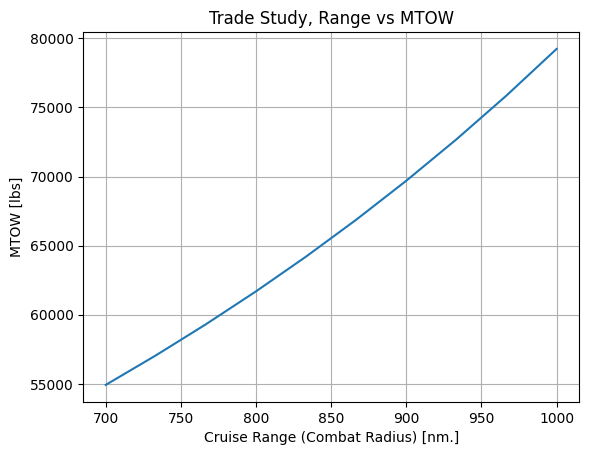

In [38]:
n = 10
cruise = np.linspace(700, 1000, n)
MTOW_c = np.empty(n)
for i, cruise in enumerate(cruise):
    performance = {
        "M_cruise"  : 0.85,     # Cruise mach speed
        "h_cruise"  : 30000,    # Cruise altitude, FT
        "a_cruise"  : 994.3,    # Speed of sound at cruise, FT/s
        "R_cruise"  : cruise,   # Cruise distance (Combat Radius), Nautical Miles
        "E_loiter"  : 20,       # Loiter time, min
        "M_dash"    : 0.85,     # Dash mach speed
        "a_dash"    : 1116,     # Speed of sound at SL, FT/s
        "R_dash"    : 100,      # Dash distnace, Nautical Miles
        "C_cruise"  : 0.8,      # Engine SFC in Cruise, 1/hr
        "C_dash"    : 1.0,      # Engine SFC in Dash (Max-non-afterburning), 1/hr
        "C_loiter"  : 0.7,      # Engine SFC in Loiter, 1/hr
        "C_after"   : 1.8,      # Engine SFC with Afterburner, 1/hr
        "E_combat"  : 2,        # Combat time, min
        "AR"        : 3,        # Estimated Aspect Ratio
        "Swet_Sref" : 4,        # Guess of Wetted Area Ratio
        "K_LD"      : 14,       # Factor in calculating L/D_max
    }
    MTOW_c[i] = MTOW_EST(mission_sequence=mission_sequence, **empty_statistic)

cruise = np.linspace(700, 1000, n)
plt.plot(cruise, MTOW_c)
plt.xlabel("Cruise Range (Combat Radius) [nm.]")
plt.ylabel("MTOW [lbs]")
plt.title("Trade Study, Range vs MTOW")
plt.grid(True)

### Trade Study on SL Dash Speed: M=0.85 -> M=0.9

,Max Takeoff Weight [lbs],Empty Weight [lbs],Fuel Weight [lbs],Payload Mass [lbs],Empty Weight Fraction,Fuel Weight Fraction
0,54924.0,31103.0,16740.0,7080,0.566,0.304794


,Max Takeoff Weight [lbs],Empty Weight [lbs],Fuel Weight [lbs],Payload Mass [lbs],Empty Weight Fraction,Fuel Weight Fraction
0,54896.0,31090.0,16726.0,7080,0.566,0.304691


,Max Takeoff Weight [lbs],Empty Weight [lbs],Fuel Weight [lbs],Payload Mass [lbs],Empty Weight Fraction,Fuel Weight Fraction
0,54868.0,31076.0,16712.0,7080,0.566,0.304589


,Max Takeoff Weight [lbs],Empty Weight [lbs],Fuel Weight [lbs],Payload Mass [lbs],Empty Weight Fraction,Fuel Weight Fraction
0,54841.0,31063.0,16698.0,7080,0.566,0.304489


,Max Takeoff Weight [lbs],Empty Weight [lbs],Fuel Weight [lbs],Payload Mass [lbs],Empty Weight Fraction,Fuel Weight Fraction
0,54815.0,31050.0,16685.0,7080,0.566,0.30439


...

,Max Takeoff Weight [lbs],Empty Weight [lbs],Fuel Weight [lbs],Payload Mass [lbs],Empty Weight Fraction,Fuel Weight Fraction
0,54762.0,31024.0,16658.0,7080,0.567,0.304196


,Max Takeoff Weight [lbs],Empty Weight [lbs],Fuel Weight [lbs],Payload Mass [lbs],Empty Weight Fraction,Fuel Weight Fraction
0,54736.0,31011.0,16645.0,7080,0.567,0.304101


,Max Takeoff Weight [lbs],Empty Weight [lbs],Fuel Weight [lbs],Payload Mass [lbs],Empty Weight Fraction,Fuel Weight Fraction
0,54711.0,30999.0,16633.0,7080,0.567,0.304007


,Max Takeoff Weight [lbs],Empty Weight [lbs],Fuel Weight [lbs],Payload Mass [lbs],Empty Weight Fraction,Fuel Weight Fraction
0,54686.0,30986.0,16620.0,7080,0.567,0.303914


Text(0.5, 1.0, 'Trade Study, Dash Speed vs MTOW')

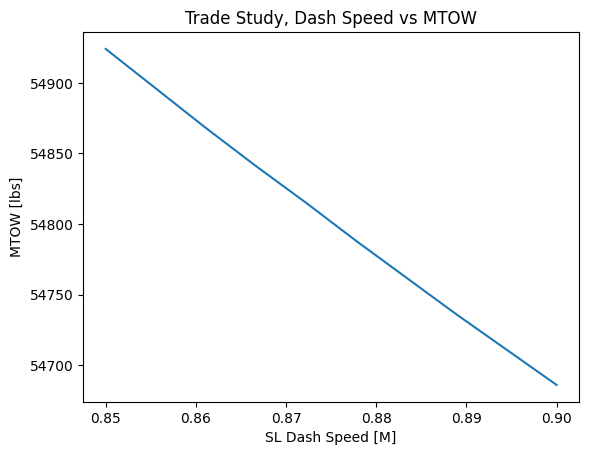

In [39]:
k = 10
dash = np.linspace(0.85, 0.9, k)
MTOW_d = np.empty(n)
for i, dash in enumerate(dash):
    performance = {
        "M_cruise"  : 0.85,     # Cruise mach speed
        "h_cruise"  : 30000,    # Cruise altitude, FT
        "a_cruise"  : 994.3,    # Speed of sound at cruise, FT/s
        "R_cruise"  : 700,      # Cruise distance (Combat Radius), Nautical Miles
        "E_loiter"  : 20,       # Loiter time, min
        "M_dash"    : dash,     # Dash mach speed
        "a_dash"    : 1116,     # Speed of sound at SL, FT/s
        "R_dash"    : 100,      # Dash distnace, Nautical Miles
        "C_cruise"  : 0.8,      # Engine SFC in Cruise, 1/hr
        "C_dash"    : 1.0,      # Engine SFC in Dash (Max-non-afterburning), 1/hr
        "C_loiter"  : 0.7,      # Engine SFC in Loiter, 1/hr
        "C_after"   : 1.8,      # Engine SFC with Afterburner, 1/hr
        "E_combat"  : 2,        # Combat time, min
        "AR"        : 3,        # Estimated Aspect Ratio
        "Swet_Sref" : 4,        # Guess of Wetted Area Ratio
        "K_LD"      : 14,       # Factor in calculating L/D_max
    }
    MTOW_d[i] = MTOW_EST(mission_sequence=mission_sequence, **empty_statistic)

dash = np.linspace(0.85, 0.9, k)
plt.plot(dash, MTOW_d)
plt.xlabel("SL Dash Speed [M]")
plt.ylabel("MTOW [lbs]")
plt.title("Trade Study, Dash Speed vs MTOW")

### Trade Study on Aspect Ratio 
Historical data shows the aspect ratio 2.5-3.5

,Max Takeoff Weight [lbs],Empty Weight [lbs],Fuel Weight [lbs],Payload Mass [lbs],Empty Weight Fraction,Fuel Weight Fraction
0,60208.0,33691.0,19437.0,7080,0.56,0.322828


,Max Takeoff Weight [lbs],Empty Weight [lbs],Fuel Weight [lbs],Payload Mass [lbs],Empty Weight Fraction,Fuel Weight Fraction
0,58839.0,33024.0,18735.0,7080,0.561,0.318417


,Max Takeoff Weight [lbs],Empty Weight [lbs],Fuel Weight [lbs],Payload Mass [lbs],Empty Weight Fraction,Fuel Weight Fraction
0,57594.0,32415.0,18099.0,7080,0.563,0.314254


,Max Takeoff Weight [lbs],Empty Weight [lbs],Fuel Weight [lbs],Payload Mass [lbs],Empty Weight Fraction,Fuel Weight Fraction
0,56457.0,31857.0,17520.0,7080,0.564,0.310318


,Max Takeoff Weight [lbs],Empty Weight [lbs],Fuel Weight [lbs],Payload Mass [lbs],Empty Weight Fraction,Fuel Weight Fraction
0,55414.0,31345.0,16989.0,7080,0.566,0.306587


,Max Takeoff Weight [lbs],Empty Weight [lbs],Fuel Weight [lbs],Payload Mass [lbs],Empty Weight Fraction,Fuel Weight Fraction
0,54453.0,30871.0,16502.0,7080,0.567,0.303045


,Max Takeoff Weight [lbs],Empty Weight [lbs],Fuel Weight [lbs],Payload Mass [lbs],Empty Weight Fraction,Fuel Weight Fraction
0,53565.0,30433.0,16052.0,7080,0.568,0.299676


,Max Takeoff Weight [lbs],Empty Weight [lbs],Fuel Weight [lbs],Payload Mass [lbs],Empty Weight Fraction,Fuel Weight Fraction
0,52741.0,30025.0,15636.0,7080,0.569,0.296465


,Max Takeoff Weight [lbs],Empty Weight [lbs],Fuel Weight [lbs],Payload Mass [lbs],Empty Weight Fraction,Fuel Weight Fraction
0,51975.0,29645.0,15250.0,7080,0.57,0.293401


,Max Takeoff Weight [lbs],Empty Weight [lbs],Fuel Weight [lbs],Payload Mass [lbs],Empty Weight Fraction,Fuel Weight Fraction
0,51260.0,29290.0,14890.0,7080,0.571,0.290473


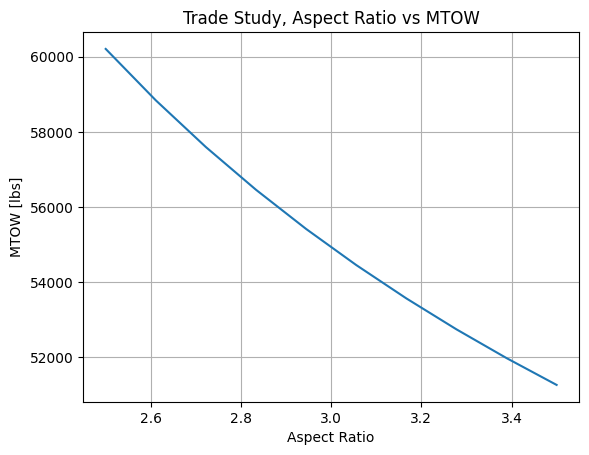

In [40]:
a = 10
ar = np.linspace(2.5, 3.5, 10)
MTOW_ar = np.empty(a)
for i, ar in enumerate(ar):
    performance = {
        "M_cruise"  : 0.85,     # Cruise mach speed
        "h_cruise"  : 30000,    # Cruise altitude, FT
        "a_cruise"  : 994.3,    # Speed of sound at cruise, FT/s
        "R_cruise"  : 700,      # Cruise distance (Combat Radius), Nautical Miles
        "E_loiter"  : 20,       # Loiter time, min
        "M_dash"    : 0.85,     # Dash mach speed
        "a_dash"    : 1116,     # Speed of sound at SL, FT/s
        "R_dash"    : 100,      # Dash distnace, Nautical Miles
        "C_cruise"  : 0.8,      # Engine SFC in Cruise, 1/hr
        "C_dash"    : 1.0,      # Engine SFC in Dash (Max-non-afterburning), 1/hr
        "C_loiter"  : 0.7,      # Engine SFC in Loiter, 1/hr
        "C_after"   : 1.8,      # Engine SFC with Afterburner, 1/hr
        "E_combat"  : 2,        # Combat time, min
        "AR"        : ar,        # Estimated Aspect Ratio
        "Swet_Sref" : 4,        # Guess of Wetted Area Ratio
        "K_LD"      : 14,       # Factor in calculating L/D_max
    }
    MTOW_ar[i] = MTOW_EST(mission_sequence=mission_sequence, **empty_statistic)

ar = np.linspace(2.5, 3.5, 10)
plt.plot(ar, MTOW_ar)
plt.xlabel("Aspect Ratio")
plt.ylabel("MTOW [lbs]")
plt.title("Trade Study, Aspect Ratio vs MTOW")
plt.grid(True)

### Trade Study on Wetted area ratio
Consulting Raymer Fig. 3.6, the wetted area ratio for military jets appears to be around 3 - 5.5

,Max Takeoff Weight [lbs],Empty Weight [lbs],Fuel Weight [lbs],Payload Mass [lbs],Empty Weight Fraction,Fuel Weight Fraction
0,48554.0,27940.0,13534.0,7080,0.575,0.278732


,Max Takeoff Weight [lbs],Empty Weight [lbs],Fuel Weight [lbs],Payload Mass [lbs],Empty Weight Fraction,Fuel Weight Fraction
0,50304.0,28814.0,14410.0,7080,0.573,0.286451


,Max Takeoff Weight [lbs],Empty Weight [lbs],Fuel Weight [lbs],Payload Mass [lbs],Empty Weight Fraction,Fuel Weight Fraction
0,52068.0,29692.0,15296.0,7080,0.57,0.293777


,Max Takeoff Weight [lbs],Empty Weight [lbs],Fuel Weight [lbs],Payload Mass [lbs],Empty Weight Fraction,Fuel Weight Fraction
0,53847.0,30572.0,16195.0,7080,0.568,0.300756


,Max Takeoff Weight [lbs],Empty Weight [lbs],Fuel Weight [lbs],Payload Mass [lbs],Empty Weight Fraction,Fuel Weight Fraction
0,55646.0,31459.0,17107.0,7080,0.565,0.307427


,Max Takeoff Weight [lbs],Empty Weight [lbs],Fuel Weight [lbs],Payload Mass [lbs],Empty Weight Fraction,Fuel Weight Fraction
0,57467.0,32353.0,18034.0,7080,0.563,0.31382


,Max Takeoff Weight [lbs],Empty Weight [lbs],Fuel Weight [lbs],Payload Mass [lbs],Empty Weight Fraction,Fuel Weight Fraction
0,59312.0,33254.0,18978.0,7080,0.561,0.319963


,Max Takeoff Weight [lbs],Empty Weight [lbs],Fuel Weight [lbs],Payload Mass [lbs],Empty Weight Fraction,Fuel Weight Fraction
0,61185.0,34166.0,19939.0,7080,0.558,0.325876


,Max Takeoff Weight [lbs],Empty Weight [lbs],Fuel Weight [lbs],Payload Mass [lbs],Empty Weight Fraction,Fuel Weight Fraction
0,63086.0,35088.0,20918.0,7080,0.556,0.33158


,Max Takeoff Weight [lbs],Empty Weight [lbs],Fuel Weight [lbs],Payload Mass [lbs],Empty Weight Fraction,Fuel Weight Fraction
0,65018.0,36021.0,21917.0,7080,0.554,0.337092


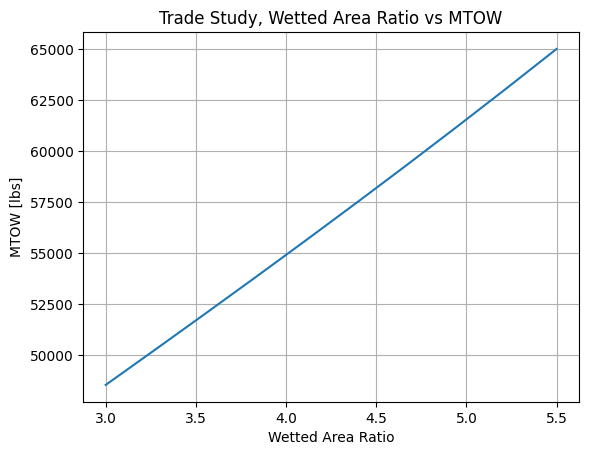

In [41]:
w = 10
w_ratio = np.linspace(3, 5.5, w)
MTOW_w = np.empty(w)
for i, w_ratio in enumerate(w_ratio):
    performance = {
        "M_cruise"  : 0.85,     # Cruise mach speed
        "h_cruise"  : 30000,    # Cruise altitude, FT
        "a_cruise"  : 994.3,    # Speed of sound at cruise, FT/s
        "R_cruise"  : 700,      # Cruise distance (Combat Radius), Nautical Miles
        "E_loiter"  : 20,       # Loiter time, min
        "M_dash"    : 0.85,     # Dash mach speed
        "a_dash"    : 1116,     # Speed of sound at SL, FT/s
        "R_dash"    : 100,      # Dash distnace, Nautical Miles
        "C_cruise"  : 0.8,      # Engine SFC in Cruise, 1/hr
        "C_dash"    : 1.0,      # Engine SFC in Dash (Max-non-afterburning), 1/hr
        "C_loiter"  : 0.7,      # Engine SFC in Loiter, 1/hr
        "C_after"   : 1.8,      # Engine SFC with Afterburner, 1/hr
        "E_combat"  : 2,        # Combat time, min
        "AR"        : 3,        # Estimated Aspect Ratio
        "Swet_Sref" : w_ratio,        # Guess of Wetted Area Ratio
        "K_LD"      : 14,       # Factor in calculating L/D_max
    }
    MTOW_w[i] = MTOW_EST(mission_sequence=mission_sequence, **empty_statistic)

w_ratio = np.linspace(3, 5.5, w)
plt.plot(w_ratio, MTOW_w)
plt.xlabel("Wetted Area Ratio")
plt.ylabel("MTOW [lbs]")
plt.title("Trade Study, Wetted Area Ratio vs MTOW")
plt.grid(True)